# Modelos para clasificación de casos de Rickettsiosis

En este notebook se hicieron pruebas con los modelos:
- Logistic Regression
- Random Forest
- SVM
- Gradient Boosting


Equipo:
- Mario Castro
- Oscar Senday
- Esthefania Ortega

## 1. Carga de librerías y datos

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_score, train_test_split, GridSearchCV, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

import dagshub
import mlflow

In [49]:
df = pd.read_csv('../data/processed/rick_feat_selected.csv')

In [50]:
df['estatus_caso'].value_counts()

estatus_caso
0    1769
1     489
Name: count, dtype: int64

**Estatus de caso:**
- 0 : descartado
- 1 : confirmado

In [51]:
''' Omitido ya que el archivo de datos ya está filtrado para casos confirmados y descartados
# Tenemos multiples estados, pero solo queremos predecir los confirmados (2) y probables (1)

df["target"] = (
    (df["estatus_caso"] == 1) | (df["estatus_caso"] == 2)
).astype(bool)
'''

' Omitido ya que el archivo de datos ya está filtrado para casos confirmados y descartados\n# Tenemos multiples estados, pero solo queremos predecir los confirmados (2) y probables (1)\n\ndf["target"] = (\n    (df["estatus_caso"] == 1) | (df["estatus_caso"] == 2)\n).astype(bool)\n'

In [52]:
#df['target'].value_counts()

In [53]:
#X = df.drop(columns=["estatus_caso", "target"])
#y = df["target"]

X = df.drop(columns=["estatus_caso"])
y = df["estatus_caso"]

----

## 1.1. Configuración de MLOps

In [54]:
dagshub.init(repo_owner='Mario-ACL', repo_name='ml_project', mlflow=True)

Initialized MLflow to track repo "Mario-ACL/ml_project"

Repository Mario-ACL/ml_project initialized!

## 2. Preprocesamiento para los modelos

Split para todos los modelos:

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [56]:
numeric_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns

''' Omitido porque el archivo de datos ya está imputado y codificado
categorical_cols = X.select_dtypes(
    include=["object", "category", "str"]
).columns
'''

' Omitido porque el archivo de datos ya está imputado y codificado\ncategorical_cols = X.select_dtypes(\n    include=["object", "category", "str"]\n).columns\n'

In [57]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

#categorical_transformer = Pipeline([
#    ("imputer", SimpleImputer(strategy="most_frequent")),
#    ("onehot", OneHotEncoder(handle_unknown="ignore"))
#])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    #("cat", categorical_transformer, categorical_cols)
])

In [58]:
# =========================
# Models + parameter grids
# =========================

model_grids = {

    "Logistic Regression": {
        "model": LogisticRegression(class_weight='balanced', random_state=42, max_iter=5000),
        "params": {
            "model__C": [0.01, 0.03, 0.05, 1],
            "model__solver": ["liblinear", "lbfgs"]
        }
    },

    "SVM": {
        "model": SVC(class_weight='balanced', probability=True),
        "params": {
            "model__C": [0.1, 1, 10],
            "model__kernel": ["linear", "rbf"],
            "model__gamma": ["scale", "auto"]
        }
    },

    "Random Forest": {
        "model": RandomForestClassifier(class_weight='balanced', random_state=42),
        "params": {
            "model__n_estimators": [100, 300],
            "model__max_depth": [None, 10, 20],
            "model__min_samples_split": [2, 5],
            "model__min_samples_leaf": [1, 2]
        }
    },

    "Gradient Boosting": {
        "model": GradientBoostingClassifier(random_state=42),
        "params": {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.01, 0.1],
            "model__max_depth": [3, 5]
        }
    }
}

## 3. Método de validación

In [59]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## 4. Entrenamiento y resultados

Despues de seleccionar los hiperparametros, el codigo siguiente es para el reporte de resultados y entrenamientos:

In [61]:
results = []

best_models = {}

for name, config in model_grids.items():

    print(f"\n Entrenando modelo {name}...")

    with mlflow.start_run(run_name=name):
            
        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", config["model"])
        ])

        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=config["params"],
            cv=cv,
            scoring="recall", #Cambie a recall para priorizar la captura de casos positivos
            n_jobs=-1,
            verbose=1
        )
        if name == "Gradient Boosting":
            weights = compute_sample_weight(class_weight='balanced', y=y_train)
            grid_search.fit(X_train, y_train, model__sample_weight=weights)
        else:
            grid_search.fit(X_train, y_train)

        best_model = grid_search.best_estimator_

        y_pred = best_model.predict(X_test)
        y_prob = best_model.predict_proba(X_test)[:, 1]

        results.append({
            "Model": name,
            "Best Params": grid_search.best_params_,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1": f1_score(y_test, y_pred),
            "ROC-AUC": roc_auc_score(y_test, y_prob)
        })

        best_models[name] = best_model

        print("\n Mejores parametros:")
        print(grid_search.best_params_)

        print("\n Reporte de clasificación:")
        print(classification_report(y_test, y_pred))

        mlflow.log_params(grid_search.best_params_)
        mlflow.log_param("class_weight", 'balanced')
        mlflow.log_metrics({
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred),
            "especificidad": recall_score(y_test, y_pred, pos_label=0),
            "recall": recall_score(y_test, y_pred),
            "f1-score": f1_score(y_test, y_pred),
            "auc-roc": roc_auc_score(y_test, y_prob),
        })


 Entrenando modelo Logistic Regression...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

 Mejores parametros:
{'model__C': 0.01, 'model__solver': 'liblinear'}

 Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.92      0.82      0.87       354
           1       0.53      0.72      0.61        98

    accuracy                           0.80       452
   macro avg       0.72      0.77      0.74       452
weighted avg       0.83      0.80      0.81       452

🏃 View run Logistic Regression at: https://dagshub.com/Mario-ACL/ml_project.mlflow/#/experiments/0/runs/7171ae067bdd4e4aadaca7d20e3a4437
🧪 View experiment at: https://dagshub.com/Mario-ACL/ml_project.mlflow/#/experiments/0

 Entrenando modelo SVM...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

 Mejores parametros:
{'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}

 Reporte de clasificación:
              precision    recall  f1-score

In [42]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="Recall",
    ascending=False
)

,Model,Best Params,Accuracy,Precision,Recall,F1,ROC-AUC
3,Gradient Boosting,"{'model__learning_rate': 0.1, 'model__max_dept...",0.834071,0.682540,0.438776,0.534161,0.781924
2,Random Forest,"{'model__max_depth': None, 'model__min_samples...",0.829646,0.666667,0.428571,0.521739,0.786320
0,Logistic Regression,"{'model__C': 0.01, 'model__solver': 'liblinear'}",0.825221,0.650794,0.418367,0.509317,0.837095
1,SVM,"{'model__C': 10, 'model__gamma': 'scale', 'mod...",0.818584,0.629032,0.397959,0.487500,0.746498


Generando curvas de aprendizaje:

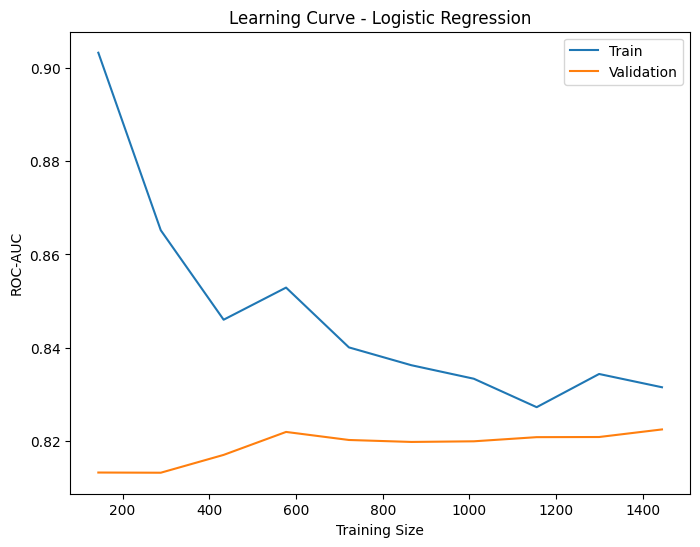

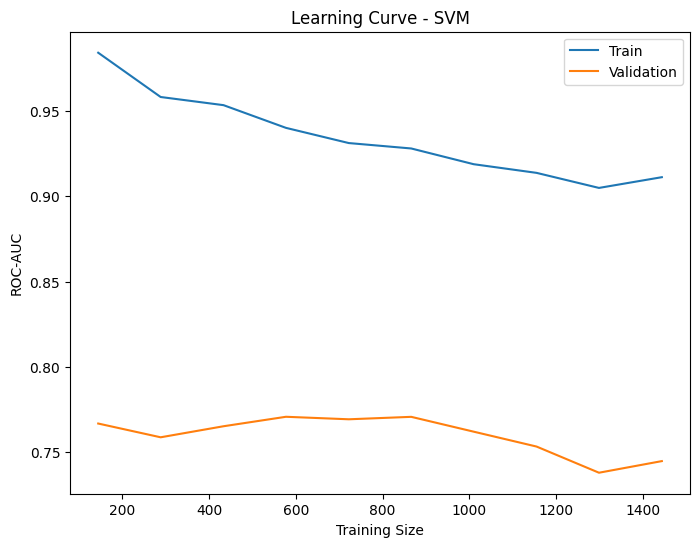

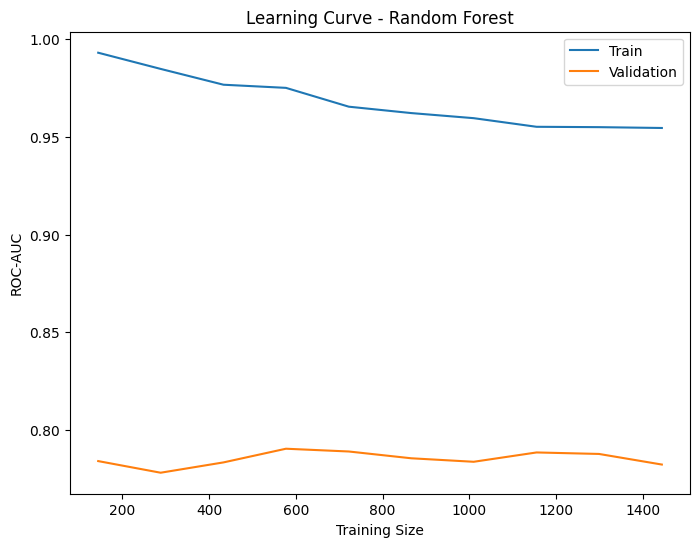

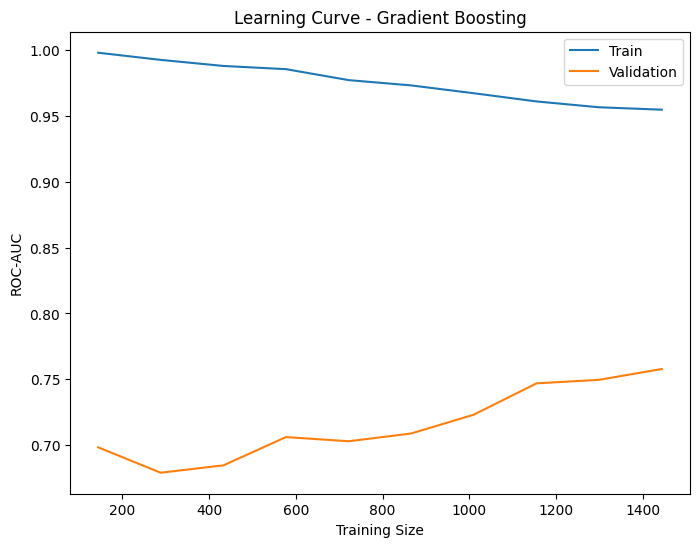

In [45]:
for name, model in best_models.items():

    train_sizes, train_scores, val_scores = learning_curve(
        estimator=model,
        X=X_train,
        y=y_train,
        cv=5,
        scoring="roc_auc",
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    plt.figure(figsize=(8, 6))

    plt.plot(train_sizes, train_mean, label="Train")
    plt.plot(train_sizes, val_mean, label="Validation")

    plt.title(f"Learning Curve - {name}")

    plt.xlabel("Training Size")
    plt.ylabel("ROC-AUC")

    plt.legend()

    plt.show()